In [1]:
from simfile import SimFile
from simulation import Simulation
from validation import switchOffAllEffects, fitGaussian2D
import os
import matplotlib.pyplot as plt
import referenceFrames as rf
import numpy as np
import math
import scipy.constants as constants

In [2]:
sim = Simulation("PSF")
switchOffAllEffects(sim)
sim.outputDir = os.environ["PLATO_WORKDIR"]

# One full-frame exposure

sim["ObservingParameters/NumExposures"] = 1
sim["CCD/IncludeConvolution"] = "yes"

starCatalogFilename = os.environ["PLATO_WORKDIR"] + "generatedFromPixelCoordinates.starcat"
sim["ObservingParameters/StarCatalogFile"] = starCatalogFilename

dim = 20
sim["SubField/NumRows"] = dim
sim["SubField/NumColumns"] = dim

sim["ControlHDF5Content/WriteSubPixelImages"] = "yes"
numSubPixels = sim["SubField/SubPixels"]

In [3]:
sim["PSF/Model"] = "MappedGaussian"
sigma = sim["PSF/MappedGaussian/Sigma"]

# Offset within pixel

In [4]:
offsets = np.arange(0.0, 1, 0.1 / numSubPixels)
position = 100

fittedSigmaPixel = np.array([])
fittedRowsPixel = np.array([])
fittedColumnsPixel = np.array([])
fittedSigmaSubPixel = np.array([])
fittedRowsSubPixel = np.array([])
fittedColumnsSubPixel = np.array([])

sim["SubField/ZeroPointRow"] = position - dim // 2
sim["SubField/ZeroPointColumn"] = position - dim // 2
    
for offset in offsets:

    sim.createStarCatalogFileFromPixelCoordinates(np.array([position + offset]), np.array([position + offset]), np.array([12.5]), np.array([1]), starCatalogFilename)

    output = sim.run(removeOutputFile = True)
    image = output.getImage(0)
    subPixelImage = output.getSubPixelImage(0)
    
    print("Offset:", offset)
    print("******* \n")
    
    params = fitGaussian2D(image, np.max(image), dim / 2, dim / 2, sigma, sigma, subtractConstant = True)
    print("Pixel level:")
    print("------------")
    print("Position:", params[1], params[2])
    print("Sigma:", params[3], "\n")
    fittedSigmaPixel = np.append(fittedSigmaPixel, params[3])
    fittedRowsPixel = np.append(fittedRowsPixel, params[1])
    fittedColumnsPixel = np.append(fittedColumnsPixel, params[2])

    params = fitGaussian2D(subPixelImage, np.max(subPixelImage), dim * numSubPixels / 2, dim * numSubPixels / 2, sigma * numSubPixels, sigma * numSubPixels, subtractConstant = True)
    print("Sub-pixel level:")
    print("----------------")
    print("Position:", params[1] / numSubPixels, params[2] / numSubPixels)
    print("Sigma:", params[3] / numSubPixels)
    fittedSigmaSubPixel = np.append(fittedSigmaSubPixel, params[3] / numSubPixels)
    fittedRowsSubPixel = np.append(fittedRowsSubPixel, params[1] / numSubPixels)
    fittedColumnsSubPixel = np.append(fittedColumnsSubPixel, params[2] / numSubPixels)



Offset: 0.0
******* 

Pixel level:
------------
Position: 9.438208412264942 9.438208418082656
Sigma: 0.7011502539879009 

Sub-pixel level:
----------------
Position: 9.874999998805455 9.875000005381038
Sigma: 0.6390004212100912


Offset: 0.0125
******* 

Pixel level:
------------
Position: 9.561791586231026 9.561791585352433
Sigma: 0.7011502169977406 

Sub-pixel level:
----------------
Position: 10.000000003097252 9.999999999319336
Sigma: 0.6390004179659305


Offset: 0.025
******* 

Pixel level:
------------
Position: 9.561791586231026 9.561791585352433
Sigma: 0.7011502169977406 

Sub-pixel level:
----------------
Position: 10.000000003097252 9.999999999319336
Sigma: 0.6390004179659307


Offset: 0.037500000000000006
******* 

Pixel level:
------------
Position: 9.561791586231026 9.561791585352433
Sigma: 0.7011502169977406 

Sub-pixel level:
----------------
Position: 10.000000003097252 9.999999999319336
Sigma: 0.639000417965931


Offset: 0.05
******* 

Pixel level:
------------
Posit

Sub-pixel level:
----------------
Position: 10.375000003989607 10.375000014019859
Sigma: 0.6390004156270775


Offset: 0.45
******* 

Pixel level:
------------
Position: 9.9370172999098 9.93701726956779
Sigma: 0.7045927258271353 

Sub-pixel level:
----------------
Position: 10.37500000398962 10.375000014019852
Sigma: 0.6390004156270885


Offset: 0.4625
******* 

Pixel level:
------------
Position: 9.9370172999098 9.93701726956779
Sigma: 0.7045927258271353 

Sub-pixel level:
----------------
Position: 10.375000003989603 10.37500001401986
Sigma: 0.6390004156270823


Offset: 0.47500000000000003
******* 

Pixel level:
------------
Position: 9.9370172999098 9.93701726956779
Sigma: 0.7045927258271353 

Sub-pixel level:
----------------
Position: 10.375000003989607 10.375000014019859
Sigma: 0.6390004156270775


Offset: 0.48750000000000004
******* 

Pixel level:
------------
Position: 9.9370172999098 9.93701726956779
Sigma: 0.7045927258271353 

Sub-pixel level:
----------------
Position: 10.375



Offset: 0.875
******* 

Pixel level:
------------
Position: 10.438208363476695 10.438208374343048
Sigma: 0.7011502740521731 

Sub-pixel level:
----------------
Position: 10.87499997753498 10.874999988914018
Sigma: 0.6390004285376226


Offset: 0.8875000000000001
******* 

Pixel level:
------------
Position: 10.438208363476695 10.438208374343048
Sigma: 0.7011502740521731 

Sub-pixel level:
----------------
Position: 10.87499997753498 10.874999988914018
Sigma: 0.6390004285376225


Offset: 0.9
******* 

Pixel level:
------------
Position: 10.438208363476695 10.438208374343048
Sigma: 0.7011502740521731 

Sub-pixel level:
----------------
Position: 10.87499997753498 10.874999988914018
Sigma: 0.6390004285376226


Offset: 0.9125000000000001
******* 

Pixel level:
------------
Position: 10.438208363476695 10.438208374343048
Sigma: 0.7011502740521731 

Sub-pixel level:
----------------
Position: 10.87499997753498 10.874999988914018
Sigma: 0.6390004285376226


Offset: 0.925
******* 

Pixel leve

## Fitted Width

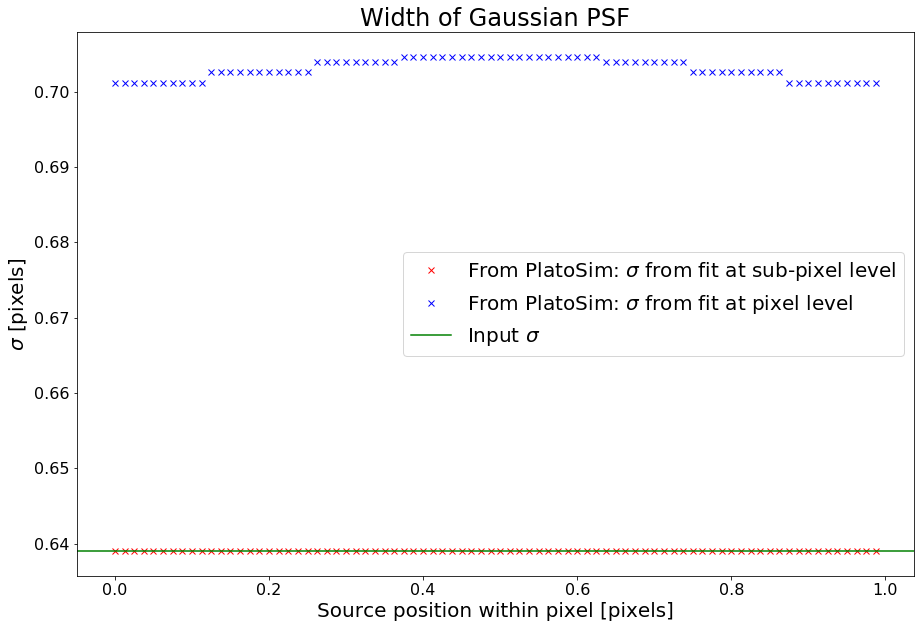

In [5]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)



plt.plot(offsets, fittedSigmaSubPixel, "rx", label = "From PlatoSim: $\\sigma$ from fit at sub-pixel level")
plt.plot(offsets, fittedSigmaPixel, "bx", label = "From PlatoSim: $\\sigma$ from fit at pixel level")

plt.axhline(y = sigma, color = "g", label = "Input $\\sigma$")


########
# Layout
########

plt.title("Width of Gaussian PSF", fontsize = 24)
plt.xlabel("Source position within pixel [pixels]", fontsize = 20)
plt.ylabel("$\\sigma$ [pixels]", fontsize = 20)

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)

## Fitted Position

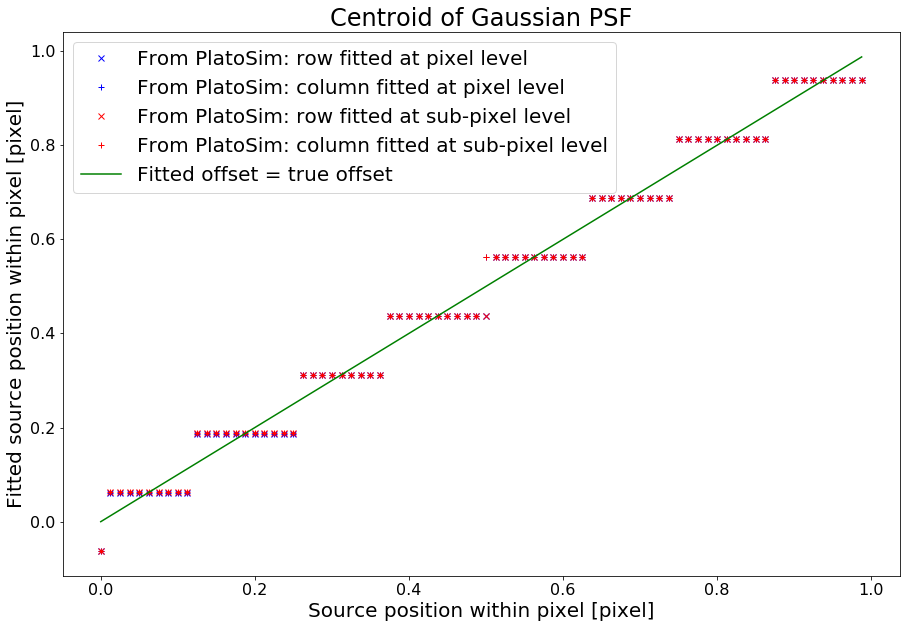

In [6]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)



plt.plot(offsets, fittedRowsPixel + 0.5 - (dim / 2), "bx", label = "From PlatoSim: row fitted at pixel level")
plt.plot(offsets, fittedColumnsPixel + 0.5 - (dim / 2), "b+", label = "From PlatoSim: column fitted at pixel level")

plt.plot(offsets, fittedRowsSubPixel + 0.5 / numSubPixels - (dim / 2), "rx", label = "From PlatoSim: row fitted at sub-pixel level")
plt.plot(offsets, fittedColumnsSubPixel + 0.5 / numSubPixels - (dim / 2), "r+", label = "From PlatoSim: column fitted at sub-pixel level")

plt.plot(offsets, (dim / 2) + offsets - (dim / 2), "g", label = "Fitted offset = true offset")

########
# Layout
########

plt.title("Centroid of Gaussian PSF", fontsize = 24)
plt.xlabel("Source position within pixel [pixel]", fontsize = 20)
plt.ylabel("Fitted source position within pixel [pixel]", fontsize = 20)

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)

# Offset on CCD

In [7]:
positions = np.arange(200, 3500, 200)
offset = 0.5

fittedSigmaPixel = np.array([])
fittedSigmaSubPixel = np.array([])
totalFlux = np.array([])

distances = np.array([])

for row in positions:
    for column in positions:
        
        distance = math.sqrt(row**2 + column**2)
        distances = np.append(distances, distance)
    
        sim["SubField/ZeroPointRow"] = row - dim // 2
        sim["SubField/ZeroPointColumn"] = column - dim // 2
        
        sim.createStarCatalogFileFromPixelCoordinates(np.array([row + offset]), np.array([column + offset]), np.array([12.5]), np.array([1]), starCatalogFilename)
    
        output = sim.run(removeOutputFile = True)
        image = output.getImage(0)
        subPixelImage = output.getSubPixelImage(0)
    
        params = fitGaussian2D(image, np.max(image), dim / 2, dim / 2, sigma, sigma, subtractConstant = True)
        fittedSigmaPixel = np.append(fittedSigmaPixel, params[3])
    
        params = fitGaussian2D(subPixelImage, np.max(subPixelImage), dim * numSubPixels / 2, dim * numSubPixels / 2, sigma * numSubPixels, sigma * numSubPixels, subtractConstant = True)
        fittedSigmaSubPixel = np.append(fittedSigmaSubPixel, params[3] / numSubPixels)
        
        totalFlux = np.append(totalFlux, np.sum(image))

(0, 18.8908)

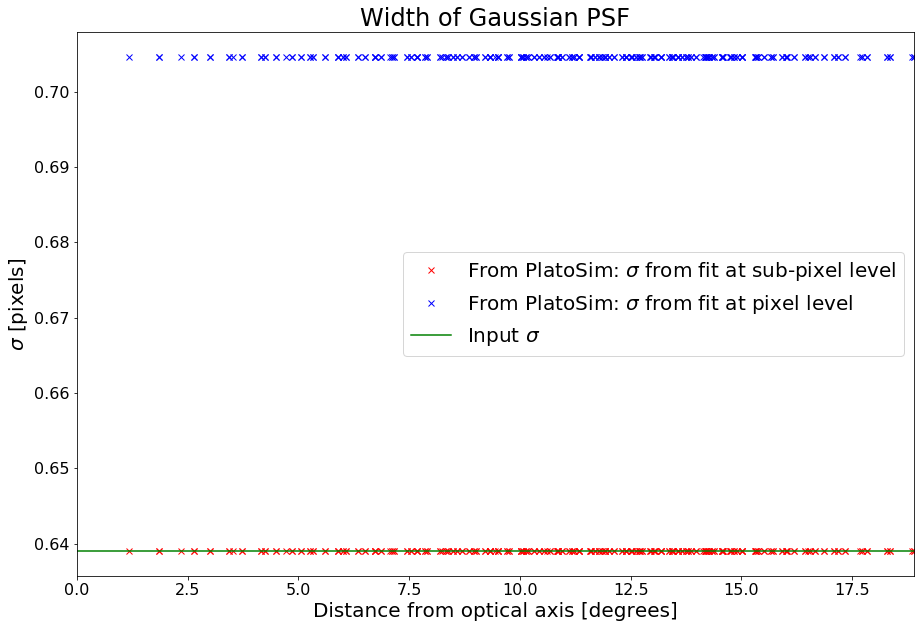

In [8]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)

# positions = np.sqrt(np.power(positions, 2) * 2)
plateScaleArcsec = 15
distances2 = distances * plateScaleArcsec / constants.degree * constants.arcsec # [pixels]
plt.plot(distances2, fittedSigmaSubPixel, "rx", label = "From PlatoSim: $\\sigma$ from fit at sub-pixel level")
plt.plot(distances2, fittedSigmaPixel, "bx", label = "From PlatoSim: $\\sigma$ from fit at pixel level")

plt.axhline(y = sigma, color = "g", label = "Input $\\sigma$")


########
# Layout
########

plt.title("Width of Gaussian PSF", fontsize = 24)
plt.xlabel("Distance from optical axis [degrees]", fontsize = 20)
plt.ylabel("$\\sigma$ [pixels]", fontsize = 20)

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)

fovDegrees = sim["CCD/Vignetting/MechanicalVignetting/RadiusFOV"]
plt.xlim([0, fovDegrees])